In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import sys

# Setting the root folder
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# --- Other Imports
from src.import_dataframe import import_dataframe
from src.plot_meldefined_magnitudes_per_class import plot_meldefined_magnitudes_per_class
from src.find_most_discriminative_bands import find_most_discriminative_bands
from src.plot_band_discriminability import plot_band_discriminability
from src.build_X_y import build_X_y
from src.threshold_f1_search import threshold_f1_search
from src.evaluate_threshold_model import evaluate_threshold_model
from src.save_metrics_csv import save_metrics_csv
from src.plot_and_save_confusion_matrices import plot_and_save_confusion_matrices


In [2]:
# import dataframe
df = import_dataframe("myUSP")


# Verify columns
print(df.columns)

Index(['file', 'age', 'gender', 'group', 'class', 'MFBM'], dtype='object')


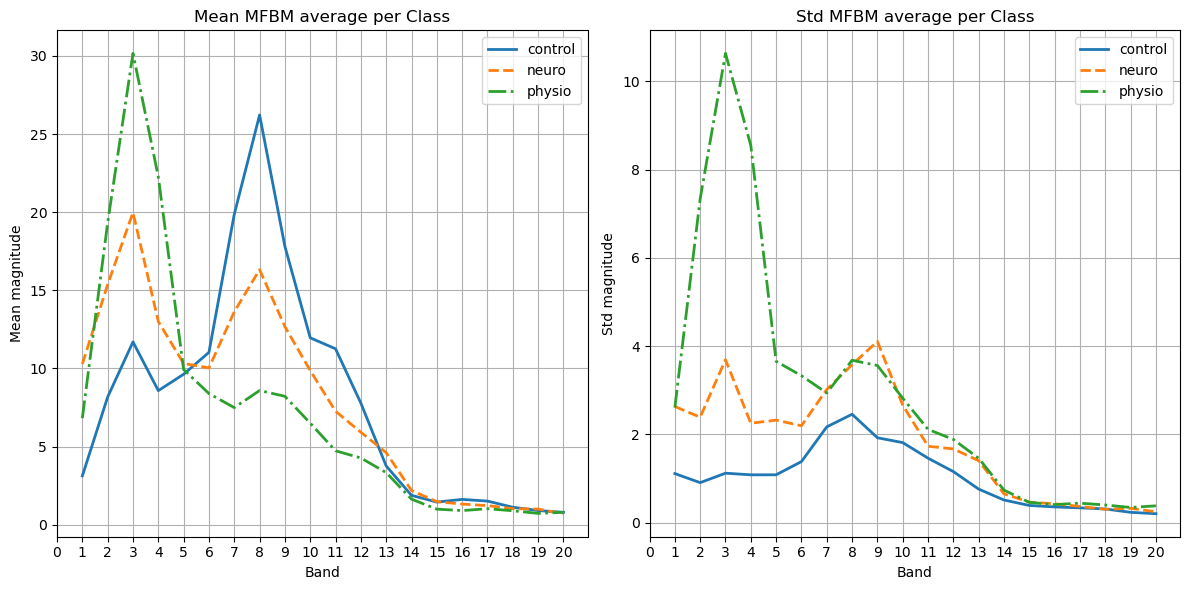

In [3]:
# Calculating band magnitude mean and std dev and adding to dataframe
# These are the features used in the Article

mean_list = []
std_list = []

for mfbm in df['MFBM']:

    # mfbm shape: (n_filters, n_frames)

    mean_bands = np.mean(mfbm, axis=1)  # (20,)
    std_bands = np.std(mfbm, axis=1)    # (20,)

    mean_list.append(mean_bands)
    std_list.append(std_bands)

df['mean_MFBM'] = mean_list
df['std_MFBM'] = std_list


# The Article joined the edema and nodules classes into one, physio
# Merging edema and nodules into 'physio' class
df.loc[df['group'].isin(['edema', 'nodulo']), 'group'] = 'physio'
#df.loc[df['class'] == 3, 'class'] = 1



# Recalculate class codes from scratch after merge
df['class'] = pd.Categorical(df['group']).codes


# Plotting mean and std magintudes per band, per class
# Returns dict with values per class
mean_dict, std_dict = plot_meldefined_magnitudes_per_class(
    df,
)

In [4]:
# Finding most discriminative bands for each pair of classes
results = find_most_discriminative_bands(mean_dict, std_dict)


Most discriminative frequency bands per class pair (Mean and Std criteria):

control vs neuro
  Mean → mel band 8
  Std  → mel band 3 

control vs physio
  Mean → mel band 3
  Std  → mel band 3 

neuro vs physio
  Mean → mel band 3
  Std  → mel band 3 


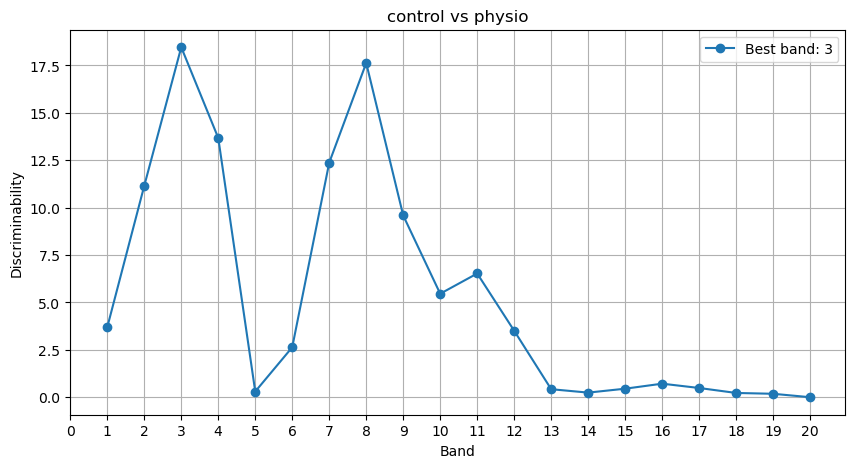

In [5]:
"""
In the original article, the most discriminative band for the mean MFBM features
was reported to be band 8. In the present implementation, however, band 3 is
identified as the most discriminative between the Control and Neuro classes.

This discrepancy is likely due to small differences in the signal processing
pipeline, numerical precision, or implementation details (e.g., interpolation,
normalization, or frame handling). Notably, the discriminability scores of
bands 3 and 8 are very close, indicating a consistent underlying trend.

For consistency with the original study and to maintain comparability of results,
band 8 will be considered as the most discriminative band for the Control vs Neuro
comparison in subsequent analyses.
"""

# Verifying band discriminability
plot_band_discriminability(mean_dict, 'control', 'physio')

In [6]:
# ---------------------------------------------------------
# Binary classification datasets (pairwise class comparisons)
#
# Each feature vector X is defined using:
# - Mean MFBM from the most discriminative band
# - Std  MFBM from the most discriminative band
#
# Band indices are zero-based:
# - Band 7 → 8th Mel band (mean feature)
# - Band 2 → 3rd Mel band (std feature)
# ---------------------------------------------------------


# Control and Physio
df_12 = df[df['group'].isin(['control', 'physio'])]

X12, y12 = build_X_y(
    df_12,
    label_map={'control': 0, 'physio': 1},
    mean_band=7,
    std_band=2
)


#Control and Neuro
df_13 = df[df['group'].isin(['control', 'neuro'])]

X13, y13 = build_X_y(
    df_13,
    label_map={'control': 0, 'neuro': 1},
    mean_band=7,
    std_band=2
)


#Physion and Neuro
df_23 = df[df['group'].isin(['physio', 'neuro'])]

X23, y23 = build_X_y(
    df_23,
    label_map={'physio': 0, 'neuro': 1},
    mean_band=2,
    std_band=2
)

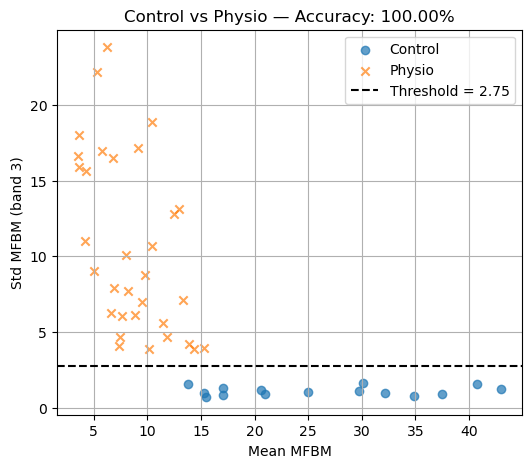

Confusion Matrix:
                   Pred Control   Pred Physio  
True Control  ->         15           0
True Physio   ->          0          32

F1-score: 1.0000
Accuracy: 1.0000


In [7]:
# Used F1-Score instead of Accuracy due to class inbalance
# control vs physio

t_opt = threshold_f1_search(X12, y12)

cm_12, f1_12, acc_12 = evaluate_threshold_model(
    X12, y12, t_opt,
    class_names=('Control', 'Physio')
)

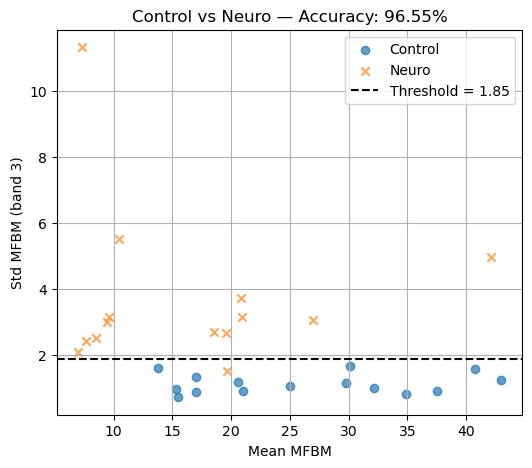

Confusion Matrix:
                   Pred Control   Pred Neuro   
True Control  ->         15           0
True Neuro    ->          1          13

F1-score: 0.9630
Accuracy: 0.9655


In [8]:
# Used F1-Score instead of Accuracy due to class inbalance
# control vs neuro

t_opt = threshold_f1_search(X13, y13)

cm_13, f1_13, acc_13 = evaluate_threshold_model(
    X13, y13, t_opt,
    class_names=('Control', 'Neuro')
)

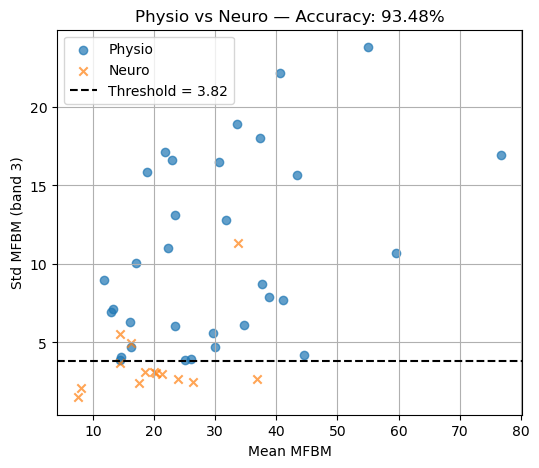

Confusion Matrix:
                   Pred Physio    Pred Neuro   
True Physio   ->         32           0
True Neuro    ->          3          11

F1-score: 0.8800
Accuracy: 0.9348


In [9]:
# Used F1-Score instead of Accuracy due to class inbalance
# physio vs neuro

t_opt = threshold_f1_search(X23, y23)

cm_23, f1_23, acc_23 = evaluate_threshold_model(
    X23, y23, t_opt,
    class_names=('Physio', 'Neuro')
)

Metrics saved to: ..\results\metrics\metrics.csv


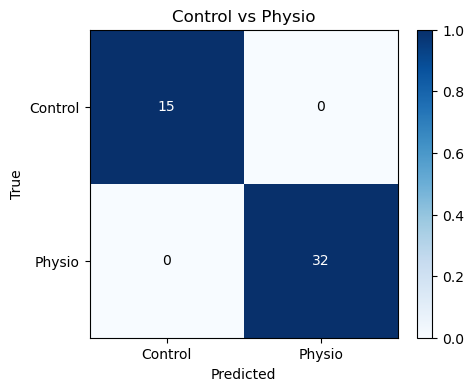

Saved: ..\results\figures\03_cm_control_vs_physio.png


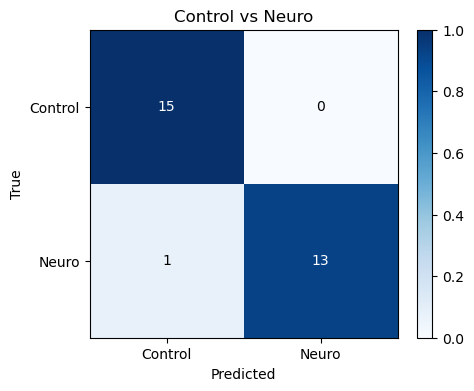

Saved: ..\results\figures\04_cm_control_vs_neuro.png


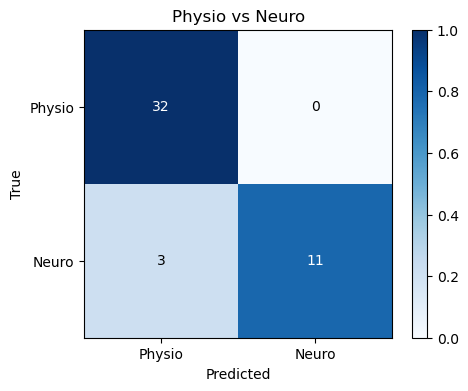

Saved: ..\results\figures\05_cm_physio_vs_neuro.png


In [10]:
"""

# Saving results/metrics

results = {
    'control_vs_physio': (cm_12, f1_12, acc_12),
    'control_vs_neuro':  (cm_13, f1_13, acc_13),
    'physio_vs_neuro':   (cm_23, f1_23, acc_23)
}

save_metrics_csv(results)

# Saving (and showing) Confusion Matrixes as Image

class_names_dict = {
    'control_vs_physio': ('Control', 'Physio'),
    'control_vs_neuro':  ('Control', 'Neuro'),
    'physio_vs_neuro':   ('Physio', 'Neuro')
}

plot_and_save_confusion_matrices(results, class_names_dict)

"""
